In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("DoctorVisits.csv")
print(df.head(15))

    Unnamed: 0  visits  gender   age  income  illness  reduced  health  \
0            1       1  female  0.19    0.55        1        4       1   
1            2       1  female  0.19    0.45        1        2       1   
2            3       1    male  0.19    0.90        3        0       0   
3            4       1    male  0.19    0.15        1        0       0   
4            5       1    male  0.19    0.45        2        5       1   
5            6       1  female  0.19    0.35        5        1       9   
6            7       1  female  0.19    0.55        4        0       2   
7            8       1  female  0.19    0.15        3        0       6   
8            9       1  female  0.19    0.65        2        0       5   
9           10       1    male  0.19    0.15        1        0       0   
10          11       1    male  0.19    0.45        1        0       0   
11          12       1    male  0.19    0.25        2        0       2   
12          13       2    male  0.19  

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [4]:
df["illness"].value_counts()

illness
1    1638
0    1554
2     946
3     542
4     274
5     236
Name: count, dtype: int64

In [5]:
df["gender"].value_counts()

gender
female    2702
male      2488
Name: count, dtype: int64

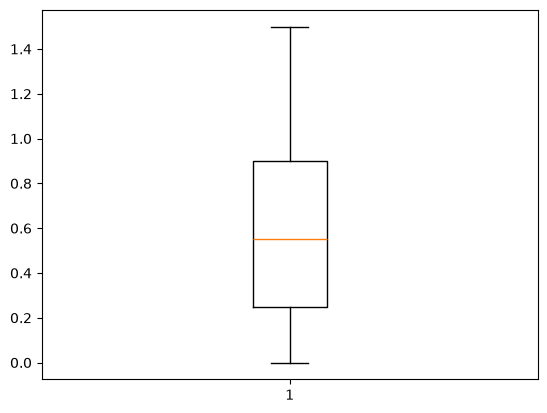

In [6]:
y = list(df.income)
plt.boxplot(y)
plt.show()

In [7]:
df.groupby(['gender', 'reduced']).mean(numeric_only=True)

Unnamed: 0    visits       age    income   illness    health
gender reduced                                                               
female 0        2524.038512  0.229322  0.465755  0.482735  1.462144  1.115098
       1        1985.768421  0.400000  0.325684  0.542105  2.242105  1.610526
       2        1622.618182  0.672727  0.391455  0.560182  2.236364  1.781818
       3         997.311111  1.333333  0.403111  0.516000  2.733333  1.733333
       4        1237.740741  0.851852  0.458889  0.466667  2.222222  2.074074
       5        1169.055556  1.444444  0.401667  0.614444  2.222222  2.500000
       6        1382.545455  1.363636  0.426364  0.622727  2.363636  1.363636
       7        1034.846154  1.384615  0.436154  0.473462  2.653846  2.230769
       8        1883.090909  1.090909  0.471818  0.404545  2.181818  4.000000
       9        1349.000000  0.500000  0.570000  0.825000  3.000000  1.000000
       10       1099.428571  2.142857  0.512857  0.421429  2.571429  2.000000
       12       1661.000000  2.000000  0.720000  0.250000  3.500000  5.500000
       13        906.000000  4.000000  0.720000  0.300000  4.500000  3.500000
       14       1392.112069  1.543103  0.551724  0.427586  2.534483  4.112069
male   0        3008.911019  0.136007  0.344703  0.694398  1.099585  0.924850
       1        2485.158537  0.304878  0.286220  0.676341  1.743902  1.256098
       2        2007.679245  0.471698  0.343585  0.653019  2.358491  1.547170
       3        1909.068966  0.724138  0.334138  0.741379  2.137931  1.689655
       4        1424.000000  0.722222  0.309444  0.869444  2.055556  2.000000
       5        1437.272727  1.136364  0.331818  0.570455  2.272727  2.818182
       6         562.000000  0.833333  0.340000  0.591667  2.500000  2.000000
       7        1716.750000  0.750000  0.314167  0.655000  2.583333  4.333333
       8         680.666667  1.333333  0.365000  0.833333  2.666667  2.000000
       9        1375.400000  2.200000  0.310000  0.392000  2.400000  2.000000
       10       1543.200000  1.800000  0.480000  0.590000  2.600000  4.600000
       11        355.500000  5.000000  0.320000  1.000000  1.500000  0.500000
       12        781.500000  2.000000  0.370000  0.515000  1.500000  1.000000
       13        508.666667  4.000000  0.510000  0.350000  3.333333  2.333333
       14       1236.069444  1.555556  0.476806  0.598611  2.375000  3.527778

<Axes: >

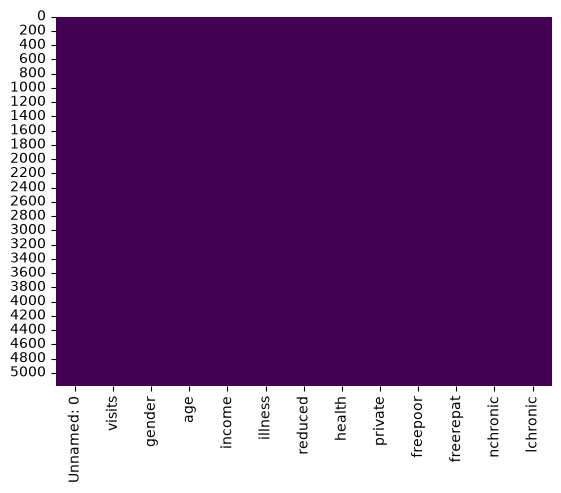

In [8]:
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

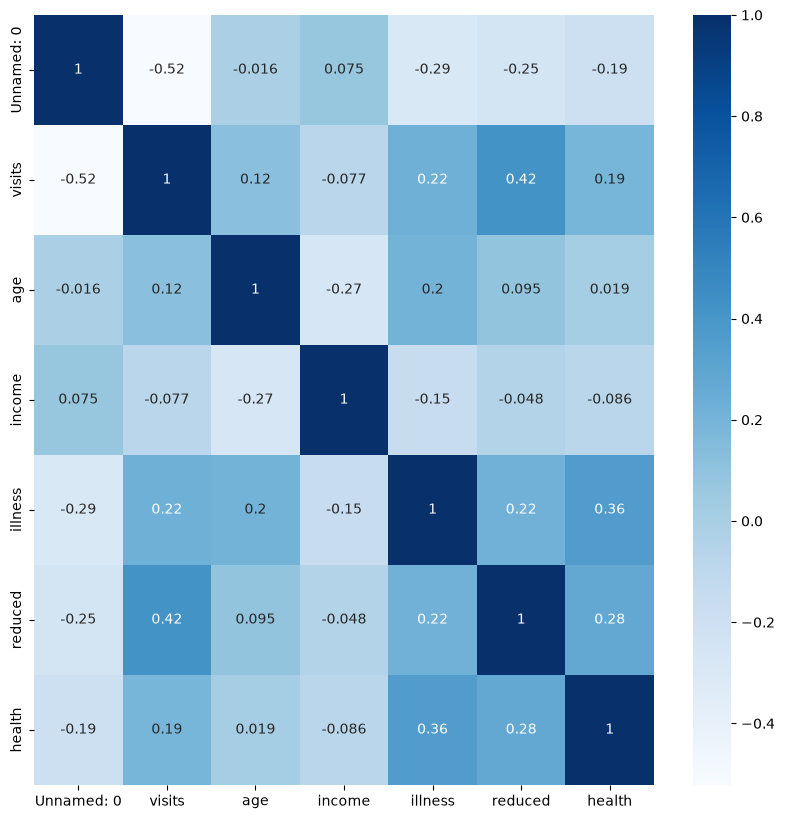

In [9]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), cbar=True, annot=True, cmap='Blues')
plt.show()

Text(0, 0.5, 'visits')

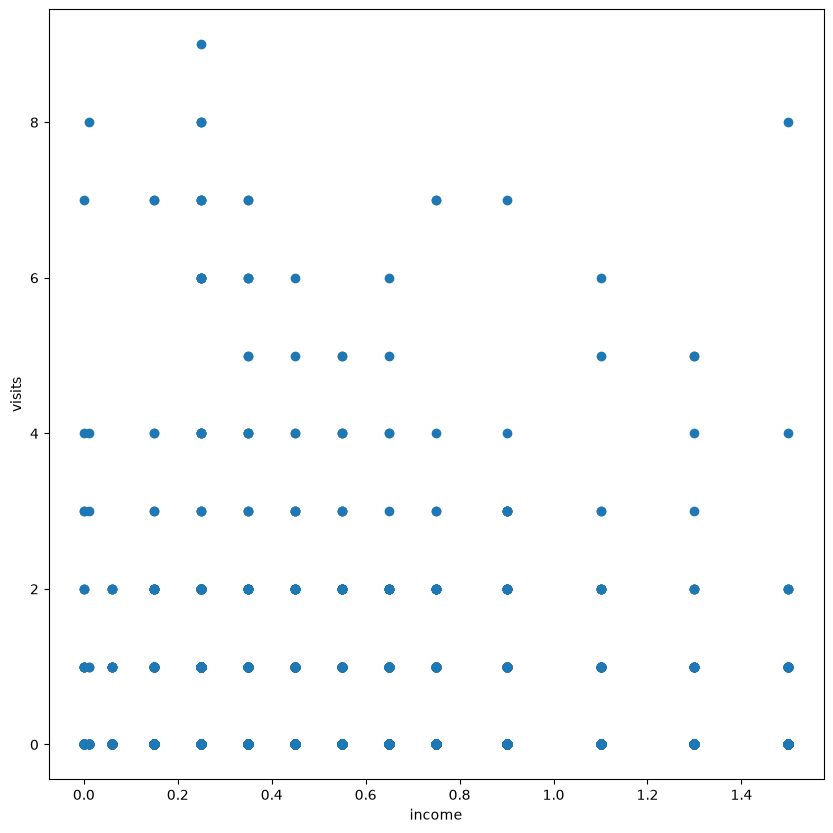

In [10]:
plt.figure(figsize=(10, 10))
plt.scatter(x='income',y='visits',data=df)
plt.xlabel('income')
plt.ylabel("visits")

<Axes: xlabel='gender', ylabel='Count'>

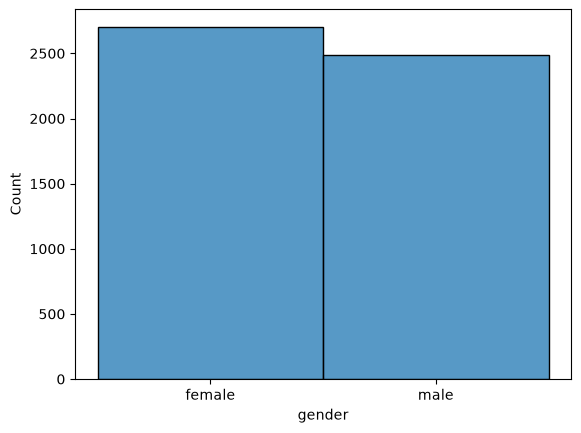

In [11]:
sns.histplot(df.gender,bins=2)

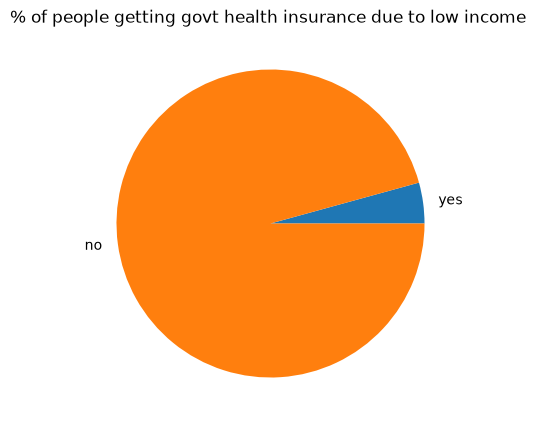

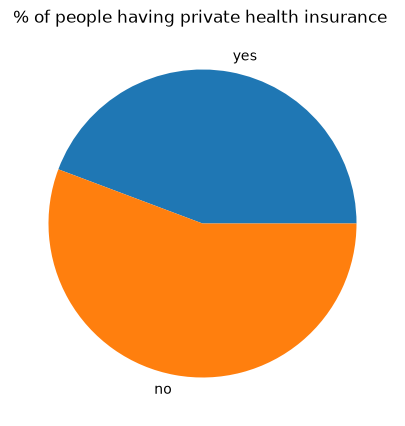

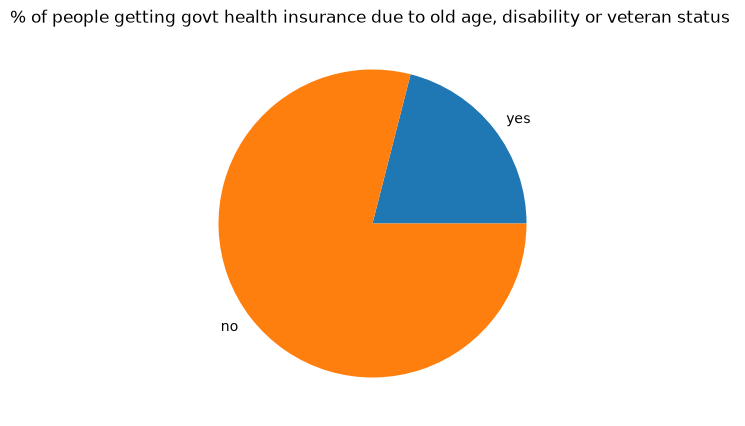

In [12]:
# % of people getting govt insurance due to low income
label=['yes','no']
Y = df[df['freepoor']=='yes']
N = df[df['freepoor']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people getting govt health insurance due to low income ")
plt.show()

# % of people having private insurance
Y = df[df['private']=='yes']
N = df[df['private']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people having private health insurance ")
plt.show()

# % of people getting govt insurance due to old age, disability or veteran status
Y = df[df['freerepat']=='yes']
N = df[df['freerepat']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people getting govt health insurance due to old age, disability or veteran status ")
plt.show()


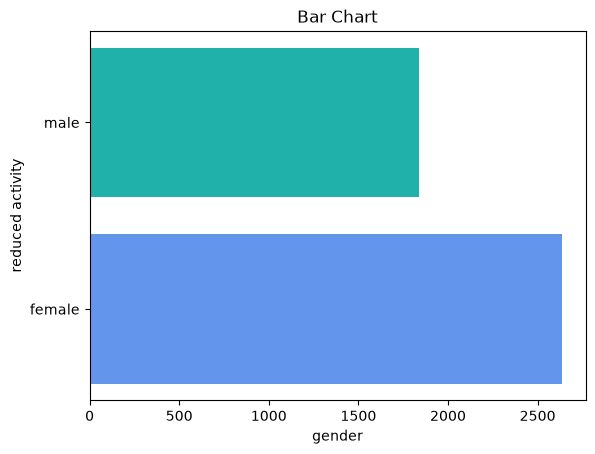

In [13]:
db= df.groupby('gender')['reduced'].sum().to_frame().reset_index()
#Creating the bar chart
plt.barh(db['gender'],db['reduced'],color = ['cornflowerblue','lightseagreen'])
#Adding the aesthetics
plt.title('Bar Chart')
plt.xlabel('gender')
plt.ylabel('reduced activity')
#Show the plot
plt.show()
